**Mickey Zhang**

CS 252: Mathematical Data Analysis and Visualization

# Lab 4b | Principal Component Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
import pandas as pd

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.figsize': [6,6]})

np.set_printoptions(suppress=True, precision=5)

## Task 1: Load and preprocess data

We are using the [Wisconsin Breast Cancer dataset](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Original)) this week. We will use principal component analysis (PCA) to gain insight about the structure of the dataset.

1. Import dataset using pandas [read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) to create a Dataframe from the url:  https://raw.githubusercontent.com/patrickmlong/Breast-Cancer-Wisconsin-Diagnostic-DataSet/master/data.csv
2. Create a `cancer_x` DataFrame which includes all of the columns that have the word "mean" in the title (*there should be 10 in total*).
3. Print out a summary of the `cancer_x` DataFrame.
4. Update `cancer_x` so that each variable is min-max normalized. Print out a summary of the updated DataFrame.
5. `diagnosis` is a categorical variable (`M` stands for "malignant" and `B` stands for "benign"). Create a `cancer_y` Series with from the column `diagnosis` and convert the data type to [categorical](https://pandas.pydata.org/docs/user_guide/categorical.html).
    1. In Task 2 of this lab you will use `diagnosis` to color-code a scatter plot of the cancer data. Use [rename_categories](https://pandas.pydata.org/pandas-docs/stable/user_guide/categorical.html#renaming-categories) to replace the categorical levels with color string names. To do this, pass in a dictionary as the parameter that maps the strings `'M'` and `'B'` to [colors](https://matplotlib.org/stable/gallery/color/named_colors.html) of your choice (e.g. `'red'`, `'blue'`). By default, the `rename_categories` method doesn't update the DataFrame when you call it, so don't forget to update the value of `cancer_y` by assigning it to the output of your `rename_categories` method call.
    2. Print out `cancer_y`. You should see the `dtype` as `category` and the values should be one of two named color strings (e.g. `'red'`, `'blue'`).

In [2]:
# Load dataset
df = pd.read_csv('https://raw.githubusercontent.com/patrickmlong/Breast-Cancer-Wisconsin-Diagnostic-DataSet/master/data.csv')

# Create cancer_x with columns containing "mean"
cancer_x = df[[col for col in df.columns if 'mean' in col]]

# Print summary
print("Summary of cancer_x:")
print(cancer_x.describe())

# Min-max normalize
cancer_x = (cancer_x - cancer_x.min()) / (cancer_x.max() - cancer_x.min())
print("\nSummary after min-max normalization:")
print(cancer_x.describe())

# Create cancer_y as categorical, rename M -> 'red', B -> 'steelblue'
cancer_y = df['diagnosis'].astype('category')
cancer_y = cancer_y.cat.rename_categories({'M': 'red', 'B': 'steelblue'})
print("\ncancer_y:")
print(cancer_y)

Summary of cancer_x:
       radius_mean  texture_mean  perimeter_mean    area_mean  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             

## Task 2: PCA

### 2a. Create and visualize a covariance matrix

1. Use the [Dataframe](https://pandas.pydata.org/pandas-docs/stable/reference/frame.html) documentation to find out how to compute the covariance matrix of the `cancer_x` columns, store it, and print its shape.
2. Use the [matplotlib](https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html) and [imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html) documentation to visualize the covariance matrix with a heatmap.
    1. Include a title
    2. Include labels for each row and column 
        1. Set the xticks, yticks, xticklabels and ytickslabels. When setting the xtick labels, rotate them so they are readable and horizontally align them to the right (i.e. `ha='right'`). You can also use `setp` to handle rotating the x-axis tick labels.
    3. Use an perceptually uniform sequential [colormap](https://matplotlib.org/tutorials/colors/colormaps.html). 
        1. Set it using the `cmap` parameter for `imshow`
    4. Include a `colorbar`. This can be achieved by assigning a variable to your `imshow` call and then passing in that variable as a parameter to `plt.colorbar`. If that does not work, the [this example code](https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html#using-the-helper-function-code-style) may be helpful.

*Your heatmap should show a 10x10 grid of colored squares.*

Covariance matrix shape: (10, 10)


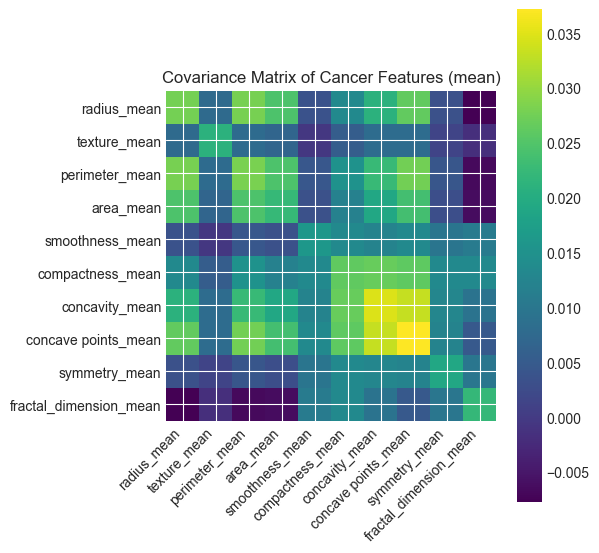

In [3]:
# Compute covariance matrix
cov_matrix = cancer_x.cov()
print("Covariance matrix shape:", cov_matrix.shape)

# Plot heatmap
fig, ax = plt.subplots()
im = ax.imshow(cov_matrix, cmap='viridis')

ax.set_title('Covariance Matrix of Cancer Features (mean)')
ax.set_xticks(range(len(cov_matrix.columns)))
ax.set_yticks(range(len(cov_matrix.columns)))
ax.set_xticklabels(cov_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(cov_matrix.columns)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### 2b. Questions

**Question 1:** What interpretations can you draw from this covariance matrix?

**Answer 1:** The covariance matrix reveals that several features are highly positively correlated with one another. In particular, `radius_mean`, `perimeter_mean`, and `area_mean` show very high covariance with each other, which makes intuitive sense since they all measure the physical size of the tumor. Similarly, `compactness_mean`, `concavity_mean`, and `concave points_mean` are strongly correlated. Features like `fractal_dimension_mean` and `smoothness_mean` show relatively little covariance with the other variables, suggesting they capture more independent information. The presence of these strong correlations indicates that there is significant redundancy in the dataset, making it a good candidate for dimensionality reduction via PCA.

### 2c. Performing PCA

Use Sci-kit Learn's [PCA class](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) to apply PCA to the cancer dataset.
1. Create an instance of the PCA class with 2 components. *This means that we will reduce the dimensionality of the cancer dataset from 10-D to 2-D*.
2. Call the method `fit_transform` with `cancer_x` as the X parameter and saving the results into a new variable representing the transformed values.
3. Print the shape of the transformed values. The transformed values should have the shape `(569, 2)`.
4. Print the first 5 rows of the transformed data.

In [4]:
from sklearn.decomposition import PCA

In [5]:
pca = PCA(n_components=2)
cancer_x_transformed = pca.fit_transform(cancer_x)

print("PCA-transformed data shape:", cancer_x_transformed.shape)
print("Transformed data:")
print(cancer_x_transformed[:5])

print('''
-------------------------------------
Your results should look like this:
-------------------------------------
PCA-transformed data shape: (569, 2)
Transformed data:
[[ 0.89009  0.51092]
 [ 0.30381 -0.39424]
 [ 0.67735 -0.07657]
 [ 0.53311  1.05071]
 [ 0.56301 -0.19896]]
-------------------------------------
''')

PCA-transformed data shape: (569, 2)
Transformed data:
[[ 0.89009  0.51092]
 [ 0.30381 -0.39424]
 [ 0.67735 -0.07657]
 [ 0.53311  1.05071]
 [ 0.56301 -0.19896]]

-------------------------------------
Your results should look like this:
-------------------------------------
PCA-transformed data shape: (569, 2)
Transformed data:
[[ 0.89009  0.51092]
 [ 0.30381 -0.39424]
 [ 0.67735 -0.07657]
 [ 0.53311  1.05071]
 [ 0.56301 -0.19896]]
-------------------------------------



### 2d. Graph a scatter plot of the transformed data

Graph a scatter plot of the transformed data using [plt.scatter](https://matplotlib.org/3.3.3/api/_as_gen/matplotlib.axes.Axes.scatter.html)
1. Scatter Parameters
    1. Graph the first principle component on the x axis (first column of the tranformed data)
    2. Graph the second principle component on the y axis (second column of the tranformed data)
    3. Use the `cancer_y` series for the color with a black edgecolor
3. Include a title, and axis labels.
4. Add a custom [legend](https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists) using mpatches.
    1. Create 1 patch with the `color` keyword argument set to whatever named color string you set for malignant
    1. Create 1 patch with the `color` keyword argument set to whatever named color string you set for benign

In [6]:
import matplotlib.patches as mpatches

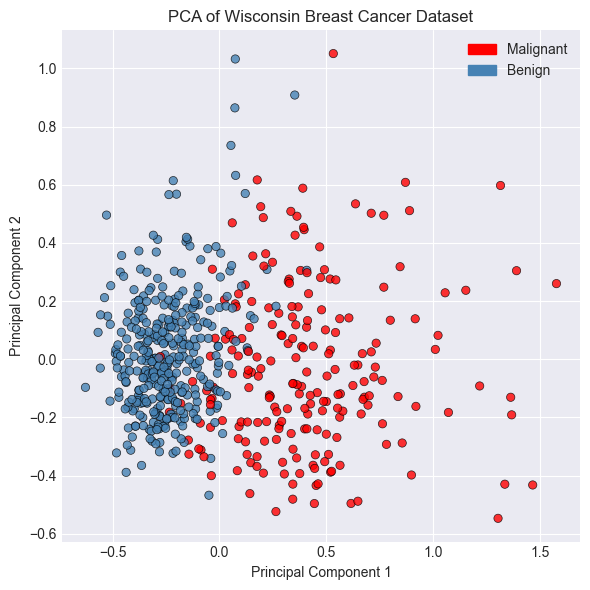

In [7]:
fig, ax = plt.subplots()

ax.scatter(cancer_x_transformed[:, 0], cancer_x_transformed[:, 1],
           c=cancer_y, edgecolors='black', linewidths=0.5, alpha=0.8)

ax.set_title('PCA of Wisconsin Breast Cancer Dataset')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')

malignant_patch = mpatches.Patch(color='red', label='Malignant')
benign_patch = mpatches.Patch(color='steelblue', label='Benign')
ax.legend(handles=[malignant_patch, benign_patch])

plt.tight_layout()
plt.show()

### 2d. Visualize the PCA loadings

In PCA, the **loadings** refer to the numbers that make up the principal component vectors (i.e. the eigenvectors). The shape of the loadings (eigenvectors) are `(k, M)` where `k` is the number of PCs and `M` is the number of original variables in the dataset. This task focuses on visualizing and interpreting what the loadings mean.

1. Print out the shape of the loadings. The [PCA class](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) of Scikit-learn stores these as a field called `components_`.
2. Use [imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html) to make a heatmap of the loadings. You should plot the **transposed** loadings, which will make your plot more readable — i.e. your heatmap should be taller than it is wide.
   1. Include a title.
   2. Set the `xticks`, `yticks`, `xticklabels` and `ytickslabels`. The y tick labels (rows) should show the original 10 variable names. The 2 x tick labels should be labeled with `'PC1'` and `'PC2'`.
   3. Use an perceptually uniform **diverging** [colormap](https://matplotlib.org/tutorials/colors/colormaps.html). Set it using the `cmap` parameter for `imshow`.
   4. To ensure that 0 is indicated by the neutral/middle color in the colormap, we need the data to be color-mapped using a range that is centered on zero. Compute the magnitude of the loadings (the maximim absolute loading). If you store that magnitude in a variable, named `mag`, then you can add the parameter and value to the imshow call: `norm=matplotlib.colors.Normalize(-mag,mag)`.
   5. Include a `colorbar`. This can be achieved by assigning a variable to your `imshow` call and then passing in that variable as a parameter to `plt.colorbar`. If that does not work, the [this example code](https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html#using-the-helper-function-code-style) may be helpful.

Loadings shape: (2, 10)


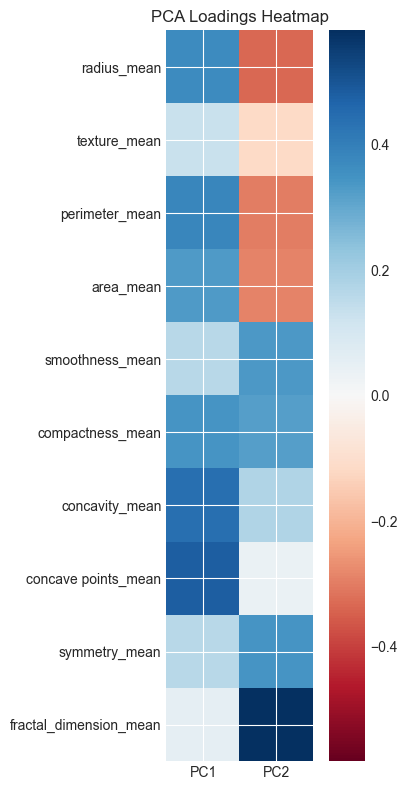

In [8]:
loadings = pca.components_
print("Loadings shape:", loadings.shape)

mag = np.max(np.abs(loadings))

fig, ax = plt.subplots(figsize=(4, 8))
im = ax.imshow(loadings.T, cmap='RdBu', norm=matplotlib.colors.Normalize(-mag, mag))

ax.set_title('PCA Loadings Heatmap')
ax.set_xticks([0, 1])
ax.set_xticklabels(['PC1', 'PC2'])
ax.set_yticks(range(len(cancer_x.columns)))
ax.set_yticklabels(cancer_x.columns)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### 2e. Questions

**Question 2:** Interpret the loadings of PC1 and PC2. Which variables in the cancer dataset are most positively and negatively correlated with each PC?

**Answer 2:** 

**PC1** captures the overall "size" and "severity" of the tumor. Nearly all 10 features load positively onto PC1, with `radius_mean`, `perimeter_mean`, `area_mean`, `concavity_mean`, and `concave points_mean` showing the strongest positive loadings. This means that tumors with high PC1 scores tend to be larger and more irregularly shaped — characteristics associated with malignancy. `fractal_dimension_mean` has the smallest (near-zero) loading on PC1.

**PC2** captures a contrast between texture/smoothness features and size features. `fractal_dimension_mean` and `smoothness_mean` load most positively onto PC2, while `concave points_mean` and `concavity_mean` load most negatively. This suggests PC2 differentiates tumors that are rough/irregular in texture but not necessarily large from those that are large and concave but smoother in texture.

## Turn in your lab

Follow the usual submission format and submit your lab on Google Classroom.